In [1]:
import scanpy as sc
import numpy as np
import scipy.stats as st

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

large_data_dir = gf_utils.large_data_dir

In [2]:
## read in filtered gene expression matrices and concatenate

adata_betaine = sc.read_h5ad(large_data_dir + 'CL3_HB_Betaine_0bp_genotype_GF.h5ad')
adata_betaine = adata_betaine[adata_betaine.obs['BC'] == 'CL3_HB_Betaine_BC001'] ### with betaine

adata_no_betaine = sc.read_h5ad(large_data_dir + 'CL3_HB_Standard.h5ad') ### no betaine

adata_betaine.obs['condition'] = 'betaine'
adata_no_betaine.obs['condition'] = 'no_betaine'

adata = sc.concat([adata_betaine, adata_no_betaine])

/tmp/ipykernel_252962/2066314846.py:8: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_betaine.obs['condition'] = 'betaine'
/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


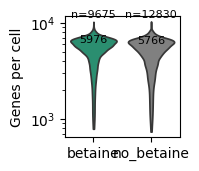

In [3]:
fig, ax = plt.subplots(figsize=(2,2))
sc.pl.violin(adata, keys='n_genes_by_counts', groupby='condition', ax=ax, show=False, stripplot=False, alpha=1, palette = {'betaine':'#1B9E77', 'no_betaine':'grey'})

# Add median labels for each group
for i, condition in enumerate(adata.obs['condition'].cat.categories):
    median_val = adata.obs[adata.obs['condition'] == condition]['n_genes_by_counts'].median()
    ax.text(i, median_val, f'{median_val:.0f}', ha='center', va='bottom', fontsize=8)
    n_cells = (adata.obs['condition'] == condition).sum()
    ax.text(i, ax.get_ylim()[1], f'n={n_cells}', ha='center', va='bottom', fontsize=8)

ax.set_yscale('log')
plt.tight_layout()
ax.set_ylabel('Genes per cell')
ax.set_xlabel('')

plt.savefig('../plots/CL3_WTA_genes_per_cell_betaine_vs_no_betaine.pdf')

In [4]:
adata_betaine.obs['n_genes_by_counts'].median() / adata_no_betaine.obs['n_genes_by_counts'].median()

1.036420395421436

In [5]:
st.mannwhitneyu(adata[adata.obs['condition'] == 'no_betaine'].obs['n_genes_by_counts'], adata[adata.obs['condition'] == 'betaine'].obs['n_genes_by_counts'], alternative='less')

MannwhitneyuResult(statistic=55840567.5, pvalue=2.2319902706592063e-38)

/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


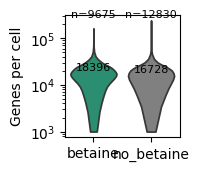

In [6]:
fig, ax = plt.subplots(figsize=(2,2))
sc.pl.violin(adata, keys='total_counts', groupby='condition', ax=ax, show=False, stripplot=False, alpha=1, palette = {'betaine':'#1B9E77', 'no_betaine':'grey'})

# Add median labels for each group
for i, condition in enumerate(adata.obs['condition'].cat.categories):
    median_val = adata.obs[adata.obs['condition'] == condition]['total_counts'].median()
    ax.text(i, median_val, f'{median_val:.0f}', ha='center', va='bottom', fontsize=8)
    n_cells = (adata.obs['condition'] == condition).sum()
    ax.text(i, ax.get_ylim()[1], f'n={n_cells}', ha='center', va='bottom', fontsize=8)

ax.set_yscale('log')
plt.tight_layout()
ax.set_ylabel('Genes per cell')
ax.set_xlabel('')

plt.savefig('../plots/CL3_WTA_counts_per_cell_betaine_vs_no_betaine.pdf')

In [7]:
adata_betaine.obs['total_counts'].median() / adata_no_betaine.obs['total_counts'].median()

1.0997459

In [8]:
st.mannwhitneyu(adata[adata.obs['condition'] == 'no_betaine'].obs['total_counts'], adata[adata.obs['condition'] == 'betaine'].obs['total_counts'], alternative='less')

MannwhitneyuResult(statistic=55429122.0, pvalue=2.4304973999333597e-43)